# Basis Refinement Method - A Hands-On 1D Tutorial

Companion to [docs/The-Basis-Refinement-Method.md](../docs/The-Basis-Refinement-Method.md).

Grinspun's 2003 thesis argues: **refine basis functions, not mesh elements.** This notebook
makes that argument concrete in 1D using quadratic B-splines, where the abstraction's
necessity becomes visible (1D linear FE is the *one* setting where element refinement and
basis refinement coincide; once you go to quadratics, they diverge).

Roadmap:
1. **Concepts you can see** - the basis at one level, nesting, why element refinement breaks.
2. **Algorithms** - active sets, Activate / Deactivate / Refine, tile coloring.
3. **A concrete PDE** - Poisson with a sharp boundary layer, adaptive vs. uniform refinement.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

np.set_printoptions(precision=3, suppress=True)

## Part 1.1 - The B-spline basis at one level

A **cardinal quadratic B-spline** $B(t)$ is the canonical piecewise-quadratic, $C^1$,
compactly-supported function with support $[0, 3]$:

$$B(t) = \begin{cases} \tfrac{1}{2}t^2 & 0 \le t < 1 \\ -t^2 + 3t - \tfrac{3}{2} & 1 \le t < 2 \\ \tfrac{1}{2}(3-t)^2 & 2 \le t < 3 \\ 0 & \text{otherwise} \end{cases}$$

A level-$p$ uniform-knot basis function is a translated, scaled copy:
$\varphi_i^{(p)}(x) = B(x / h_p - i)$ where $h_p = 2^{-p}$. Its support is $[i h_p, (i+3) h_p]$.

For homogeneous Dirichlet BCs on $[0, 1]$, we use only the **interior** functions whose
support lies entirely in $[0, 1]$: indices $i \in \{0, 1, \ldots, 2^p - 3\}$.

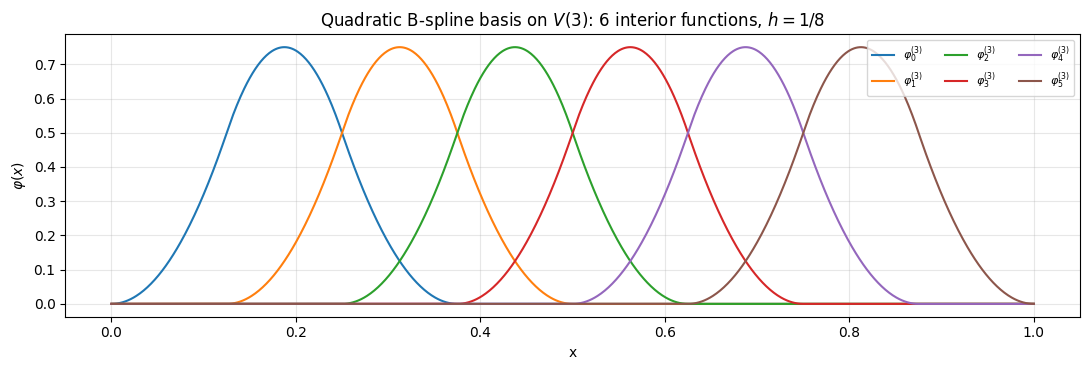

In [31]:
def B(t):
    """Cardinal quadratic B-spline. Support [0, 3], peak 0.75 at t = 1.5."""
    t = np.atleast_1d(np.asarray(t, dtype=float))
    out = np.zeros_like(t)
    m1 = (t > 0) & (t < 1)
    m2 = (t >= 1) & (t < 2)
    m3 = (t >= 2) & (t < 3)
    out[m1] = 0.5 * t[m1] ** 2
    out[m2] = -t[m2] ** 2 + 3 * t[m2] - 1.5
    out[m3] = 0.5 * (3 - t[m3]) ** 2
    return out


def Bp(t):
    """First derivative B'(t)."""
    t = np.atleast_1d(np.asarray(t, dtype=float))
    out = np.zeros_like(t)
    m1 = (t > 0) & (t < 1)
    m2 = (t >= 1) & (t < 2)
    m3 = (t >= 2) & (t < 3)
    out[m1] = t[m1]
    out[m2] = -2 * t[m2] + 3
    out[m3] = -(3 - t[m3])
    return out


def Bpp(t):
    """Second derivative B''(t). Piecewise constant."""
    t = np.atleast_1d(np.asarray(t, dtype=float))
    out = np.zeros_like(t)
    out[(t > 0) & (t < 1)] = 1.0
    out[(t > 1) & (t < 2)] = -2.0
    out[(t > 2) & (t < 3)] = 1.0
    return out


def phi(level, idx, x):
    h = 2.0 ** (-level)
    return B(x / h - idx)


def phi_p(level, idx, x):
    h = 2.0 ** (-level)
    return Bp(x / h - idx) / h


def phi_pp(level, idx, x):
    h = 2.0 ** (-level)
    return Bpp(x / h - idx) / h ** 2


def support(level, idx):
    h = 2.0 ** (-level)
    return idx * h, (idx + 3) * h


# Plot the level-3 basis on [0, 1]
xs = np.linspace(0, 1, 1001)
fig, ax = plt.subplots(figsize=(11, 3.8))
p = 3
N = 2 ** p
for i in range(N - 2):
    ax.plot(xs, phi(p, i, xs), label=fr'$\varphi_{{{i}}}^{{({p})}}$')
ax.set_title(fr'Quadratic B-spline basis on $V({p})$: {N - 2} interior functions, $h = 1/{N}$')
ax.set_xlabel('x'); ax.set_ylabel(r'$\varphi(x)$')
ax.legend(loc='upper right', ncol=3, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 1.2 - Nesting and the refinement relation

Because $V(p) \subset V(p+1)$, every coarse $\varphi_i^{(p)}$ is a finite linear
combination of fine ones. For uniform-knot quadratic B-splines this is the well-known
four-term relation:

$$\varphi_i^{(p)} \;=\; \tfrac{1}{4}\,\varphi_{2i}^{(p+1)} + \tfrac{3}{4}\,\varphi_{2i+1}^{(p+1)} + \tfrac{3}{4}\,\varphi_{2i+2}^{(p+1)} + \tfrac{1}{4}\,\varphi_{2i+3}^{(p+1)}$$

These coefficients - call them $h_k = (\tfrac{1}{4}, \tfrac{3}{4}, \tfrac{3}{4}, \tfrac{1}{4})$ -
are the only data the algorithms in Part 2 need to know about the basis. Verify numerically:

max |parent - sum_of_children| = 7.77e-16


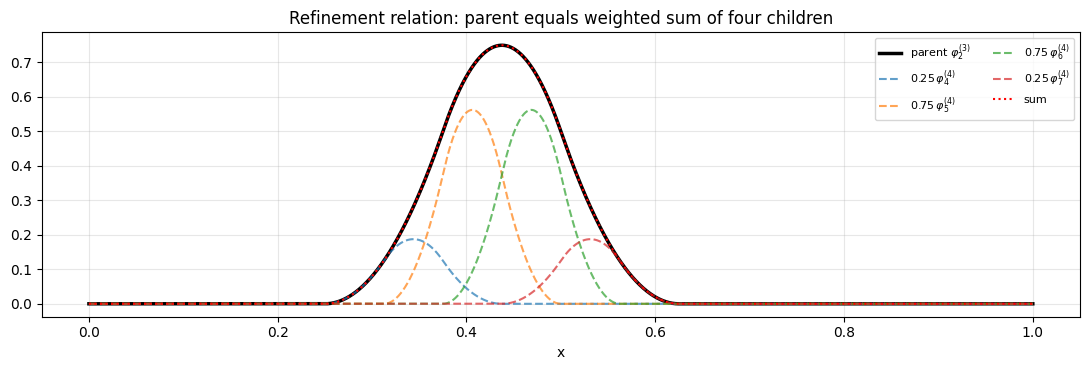

In [32]:
REFINE_COEFFS = np.array([0.25, 0.75, 0.75, 0.25])

p_test, i_test = 3, 2
xs_fine = np.linspace(0, 1, 4001)
parent = phi(p_test, i_test, xs_fine)
recon = sum(c * phi(p_test + 1, 2 * i_test + k, xs_fine) for k, c in enumerate(REFINE_COEFFS))
print(f"max |parent - sum_of_children| = {np.max(np.abs(parent - recon)):.2e}")

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(xs_fine, parent, 'k-', linewidth=2.5, label=fr'parent $\varphi_{i_test}^{{({p_test})}}$')
for k, c in enumerate(REFINE_COEFFS):
    ax.plot(xs_fine, c * phi(p_test + 1, 2 * i_test + k, xs_fine), '--', alpha=0.7,
            label=fr'${c:.2f}\,\varphi_{{{2*i_test+k}}}^{{({p_test+1})}}$')
ax.plot(xs_fine, recon, 'r:', linewidth=1.5, label='sum')
ax.set_title('Refinement relation: parent equals weighted sum of four children')
ax.set_xlabel('x'); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 1.3 - Why element refinement breaks (the headline argument)

Suppose we wanted to "refine just one interval" - the textbook FE move. For 1D linear
hat functions this works: a hat is supported on two intervals, you can split it locally.
For quadratic B-splines, support spans **three** intervals. Splitting only one of them
yields a function that's no longer in *any* of the nested spaces.

**Visual contrast.** Highlight one element, then ask: which level-$(p+1)$ basis
functions would we have to add to enrich the space *inside* that element?

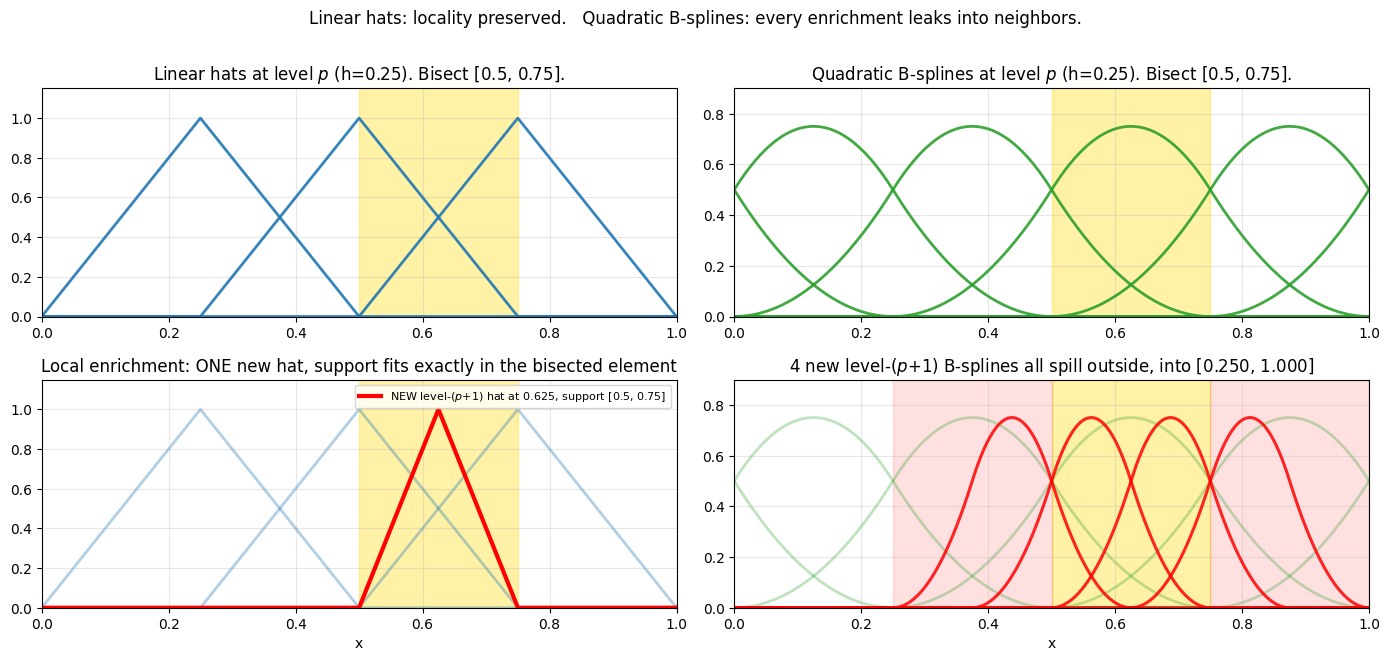

In [33]:
def hat(x, center, h):
    """Cardinal linear hat: 1 at center, 0 at center +/- h."""
    return np.maximum(0.0, 1.0 - np.abs((x - center) / h))


xs_lo = np.linspace(-0.02, 1.02, 2001)
h_p = 0.25                       # element size at level p (h = 1/4)
elem_a, elem_b = 0.5, 0.75       # element to "bisect"
elem_mid = 0.5 * (elem_a + elem_b)

fig, axes = plt.subplots(2, 2, figsize=(14, 6.5))

# --- Linear hats: top = level-p basis, bottom = locally enriched ---
ax = axes[0, 0]
for c in np.arange(h_p, 1.0, h_p):
    ax.plot(xs_lo, hat(xs_lo, c, h_p), '-', linewidth=2, color='C0', alpha=0.9)
ax.axvspan(elem_a, elem_b, color='gold', alpha=0.35, zorder=0)
ax.set_title(f'Linear hats at level $p$ (h={h_p}). Bisect [{elem_a}, {elem_b}].')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.15); ax.grid(alpha=0.3)

ax = axes[1, 0]
for c in np.arange(h_p, 1.0, h_p):
    ax.plot(xs_lo, hat(xs_lo, c, h_p), '-', linewidth=2, color='C0', alpha=0.35)
ax.plot(xs_lo, hat(xs_lo, elem_mid, h_p / 2), 'r-', linewidth=3,
        label=f'NEW level-$(p{{+}}1)$ hat at {elem_mid}, support [{elem_a}, {elem_b}]')
ax.axvspan(elem_a, elem_b, color='gold', alpha=0.35, zorder=0)
ax.set_title('Local enrichment: ONE new hat, support fits exactly in the bisected element')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.15); ax.grid(alpha=0.3)
ax.legend(loc='upper right', fontsize=8); ax.set_xlabel('x')

# --- Quadratic B-splines: top = level-p basis, bottom = supports spill ---
ax = axes[0, 1]
p_lvl = 2  # so h_{p_lvl} = 1/4 = h_p, same element grid as linear panel
for i in range(-2, 2 ** p_lvl):
    y = phi(p_lvl, i, xs_lo)
    if y.max() > 0:
        ax.plot(xs_lo, y, '-', linewidth=2, color='C2', alpha=0.9)
ax.axvspan(elem_a, elem_b, color='gold', alpha=0.35, zorder=0)
ax.set_title(f'Quadratic B-splines at level $p$ (h={h_p}). Bisect [{elem_a}, {elem_b}].')
ax.set_xlim(0, 1); ax.set_ylim(0, 0.9); ax.grid(alpha=0.3)

ax = axes[1, 1]
for i in range(-2, 2 ** p_lvl):
    y = phi(p_lvl, i, xs_lo)
    if y.max() > 0:
        ax.plot(xs_lo, y, '-', linewidth=2, color='C2', alpha=0.3)
# All level-(p+1) B-splines whose support intersects [elem_a, elem_b]
h_fine = 2.0 ** (-(p_lvl + 1))
overlap_idx = []
for j in range(-3, 2 ** (p_lvl + 1) + 1):
    sa, sb = j * h_fine, (j + 3) * h_fine
    if sa < elem_b and sb > elem_a:
        overlap_idx.append(j)
spill_a = min(j * h_fine for j in overlap_idx)
spill_b = max((j + 3) * h_fine for j in overlap_idx)
for j in overlap_idx:
    ax.plot(xs_lo, phi(p_lvl + 1, j, xs_lo), 'r-', linewidth=2.2, alpha=0.85)
ax.axvspan(elem_a, elem_b, color='gold', alpha=0.35, zorder=0)
ax.axvspan(spill_a, elem_a, color='red', alpha=0.12, zorder=0)
ax.axvspan(elem_b, spill_b, color='red', alpha=0.12, zorder=0)
ax.set_title(f'{len(overlap_idx)} new level-$(p{{+}}1)$ B-splines all spill outside, into [{spill_a:.3f}, {spill_b:.3f}]')
ax.set_xlim(0, 1); ax.set_ylim(0, 0.9); ax.grid(alpha=0.3)
ax.set_xlabel('x')

plt.suptitle('Linear hats: locality preserved.   Quadratic B-splines: every enrichment leaks into neighbors.', y=1.01)
plt.tight_layout()
plt.show()

**The algebraic version of the same picture.** Try to express the parent quadratic
B-spline using *only some* of its four children. By the refinement relation, **all four**
are needed. Drop any subset and you are left with a residual that no choice of
coefficients can eliminate.

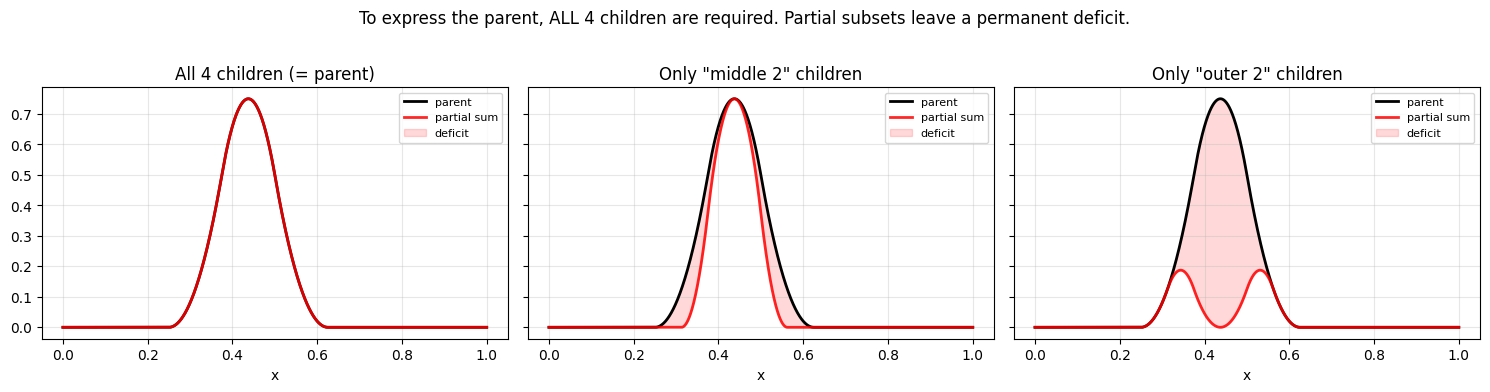

Best least-squares fit of parent using only the 2 middle children:
   coefficients (best fit) = [0.823 0.823]  (vs. true = [0.75, 0.75])
   relative residual ||parent - fit|| / ||parent|| = 0.235
   -> nonzero residual proves: parent is NOT in span(middle 2 children).


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
parent = phi(3, 2, xs_fine)
scenarios = [
    (REFINE_COEFFS, 'All 4 children (= parent)'),
    (np.array([0, 0.75, 0.75, 0]), 'Only "middle 2" children'),
    (np.array([0.25, 0, 0, 0.25]), 'Only "outer 2" children'),
]
for ax, (coeffs, title) in zip(axes, scenarios):
    recon = sum(c * phi(4, 2 * 2 + k, xs_fine) for k, c in enumerate(coeffs))
    ax.plot(xs_fine, parent, 'k-', linewidth=2, label='parent')
    ax.plot(xs_fine, recon, 'r-', linewidth=2, alpha=0.85, label='partial sum')
    ax.fill_between(xs_fine, recon, parent, color='red', alpha=0.15, label='deficit')
    ax.set_title(title); ax.legend(fontsize=8); ax.set_xlabel('x'); ax.grid(alpha=0.3)
plt.suptitle('To express the parent, ALL 4 children are required. Partial subsets leave a permanent deficit.', y=1.02)
plt.tight_layout()
plt.show()

# Quantitative: best L^2 fit using only "middle 2" children leaves residual > 0
A = np.column_stack([phi(4, 4 + k, xs_fine) for k in (1, 2)])
coeffs_ls, *_ = np.linalg.lstsq(A, parent, rcond=None)
residual_norm = np.linalg.norm(parent - A @ coeffs_ls)
parent_norm = np.linalg.norm(parent)
print(f"Best least-squares fit of parent using only the 2 middle children:")
print(f"   coefficients (best fit) = {coeffs_ls}  (vs. true = [0.75, 0.75])")
print(f"   relative residual ||parent - fit|| / ||parent|| = {residual_norm / parent_norm:.3f}")
print("   -> nonzero residual proves: parent is NOT in span(middle 2 children).")

**The conclusion that drives the rest of the thesis:** the only consistent way to
"refine locally" is to add **whole basis functions** to the active set, never partial
pieces of elements. The element-by-element view of refinement was the wrong abstraction.

---

## Part 2.1 - Active basis: data structures

An **active basis** $B$ is a set of basis functions, drawn from any level. We track:

- `coeffs : (level, idx) -> coefficient` - the active functions and their coefficients
- `active_elements` - level-$p$ dyadic intervals appearing in any active $S(\varphi)$
- `Bs(level, elem_idx)` - same-level active functions overlapping the element  *(invariant I2)*
- `Ba(level, elem_idx)` - coarser-level active functions overlapping the element  *(invariant I3)*

The thesis maintains $E$, $B_s$, $B_a$ incrementally for efficiency. We compute them on
demand here because clarity matters more than constant factors.

In [35]:
class HierarchicalBasis:
    """Active basis with Activate / Deactivate / Refine and derived I1-I3 views."""

    def __init__(self):
        self.coeffs = {}  # (level, idx) -> coefficient

    def activate(self, level, idx, coeff=0.0):
        self.coeffs.setdefault((level, idx), coeff)

    def deactivate(self, level, idx):
        self.coeffs.pop((level, idx), None)

    def refine(self, level, idx):
        """Substitution refinement: 1 Deactivate + (up to) 4 Activates with coefficient redistribution."""
        c = self.coeffs[(level, idx)]
        self.deactivate(level, idx)
        for k, w in enumerate(REFINE_COEFFS):
            child = (level + 1, 2 * idx + k)
            self.coeffs[child] = self.coeffs.get(child, 0.0) + w * c

    @property
    def active_elements(self):
        """I1: E = union of S(phi) over active phi. (Each phi_i^p covers elements (p, i+0..2).)"""
        return {(lvl, idx + k) for (lvl, idx) in self.coeffs for k in range(3)}

    def Bs(self, level, elem_idx):
        return [(level, j) for j in range(elem_idx - 2, elem_idx + 1)
                if (level, j) in self.coeffs]

    def Ba(self, level, elem_idx):
        result = []
        for q in range(level):
            ancestor = elem_idx >> (level - q)
            for j in range(ancestor - 2, ancestor + 1):
                if (q, j) in self.coeffs:
                    result.append((q, j))
        return result

    def __len__(self):
        return len(self.coeffs)


# Sanity check: build a uniform level-3 basis, refine one function, inspect.
basis = HierarchicalBasis()
for i in range(2 ** 3 - 2):
    basis.activate(3, i, coeff=1.0)
print(f"Initial active functions: {len(basis)}")
print(f"Initial active elements: {len(basis.active_elements)}")

basis.refine(3, 2)
print(f"\nAfter Refine(3, 2):")
print(f"   active functions ({len(basis)}): {sorted(basis.coeffs.keys())}")
print(f"   coefficients of the (now activated) children:")
for k in range(4):
    key = (4, 2 * 2 + k)
    if key in basis.coeffs:
        print(f"      {key}: {basis.coeffs[key]:.3f}  (refine weight {REFINE_COEFFS[k]} times old parent value 1.0)")

# Inspect Bs / Ba for a level-4 element
elem = (4, 5)
print(f"\nFor element {elem}:")
print(f"   Bs ({elem[0]}-level functions overlapping it) = {basis.Bs(*elem)}")
print(f"   Ba (coarser active functions overlapping it) = {basis.Ba(*elem)}")

Initial active functions: 6
Initial active elements: 8

After Refine(3, 2):
   active functions (9): [(3, 0), (3, 1), (3, 3), (3, 4), (3, 5), (4, 4), (4, 5), (4, 6), (4, 7)]
   coefficients of the (now activated) children:
      (4, 4): 0.250  (refine weight 0.25 times old parent value 1.0)
      (4, 5): 0.750  (refine weight 0.75 times old parent value 1.0)
      (4, 6): 0.750  (refine weight 0.75 times old parent value 1.0)
      (4, 7): 0.250  (refine weight 0.25 times old parent value 1.0)

For element (4, 5):
   Bs (4-level functions overlapping it) = [(4, 4), (4, 5)]
   Ba (coarser active functions overlapping it) = [(3, 0), (3, 1)]


## Part 2.2 - Activate, Deactivate, and the refinement relation in action

max|f_before - f_after| after Refine(3, 2): 7.77e-16
(should be ~machine eps - refinement preserves the represented function)


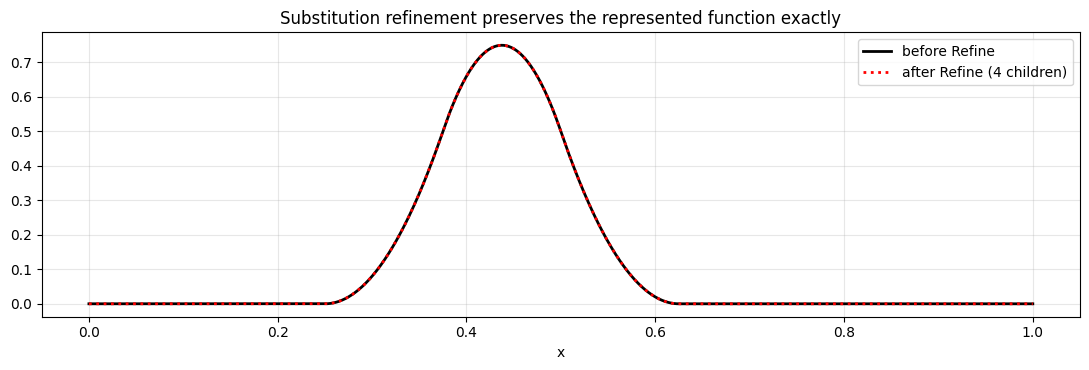

In [36]:
def evaluate(basis, xs):
    """Evaluate sum_{(lvl,idx) in B} c_{lvl,idx} * phi_{lvl,idx}(x)."""
    out = np.zeros_like(xs)
    for (lvl, idx), c in basis.coeffs.items():
        out += c * phi(lvl, idx, xs)
    return out


# Build a function as a single coarse B-spline, then refine it. The function value
# should be invariant under refinement (refinement preserves the represented function).
b = HierarchicalBasis()
b.activate(3, 2, coeff=1.0)
xs = np.linspace(0, 1, 2001)

f_before = evaluate(b, xs).copy()
b.refine(3, 2)
f_after = evaluate(b, xs)

print(f"max|f_before - f_after| after Refine(3, 2): {np.max(np.abs(f_before - f_after)):.2e}")
print("(should be ~machine eps - refinement preserves the represented function)")

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(xs, f_before, 'k-', linewidth=2, label='before Refine')
ax.plot(xs, f_after, 'r:', linewidth=2, label='after Refine (4 children)')
ax.set_title('Substitution refinement preserves the represented function exactly')
ax.set_xlabel('x'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 2.3 - Tile coloring (TCP) in 1D

For numerical quadrature we need a partition of the active region. The thesis colors
every element in the (infinite) hierarchy:

- **Black**: too coarse - has an active descendant
- **Red**: just right - active leaf, gives the integration partition
- **White**: too fine - descended from red

Theorem 4 in the thesis: the red tiles form a *minimal* partition resolving every active
element. In 1D dyadic this collapses to "active elements with no active descendants in
the active-element set" (and resolving tiles between black-coarse and white-fine, which
don't appear in the simple refinement patterns we'll exercise here).

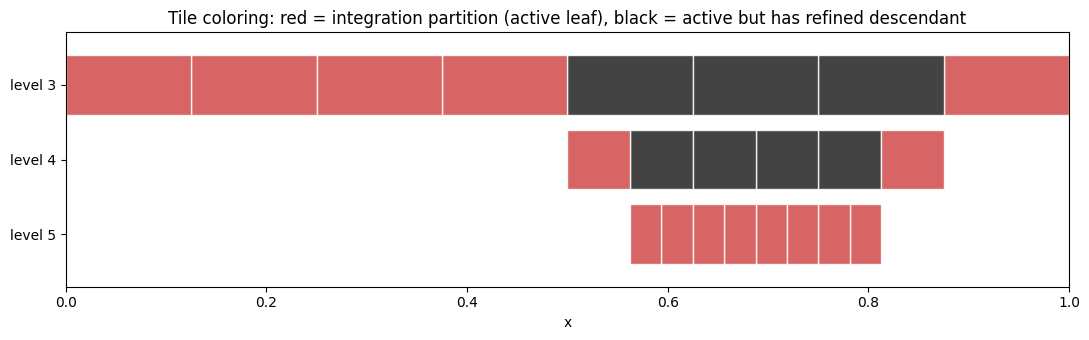

In [37]:
def color_tiles(basis):
    """Return dict (level, idx) -> 'red' | 'black' for elements in basis.active_elements."""
    elems = basis.active_elements
    if not elems:
        return {}
    max_level = max(lvl for (lvl, _) in elems)
    colors = {}
    for (p, j) in elems:
        has_desc = False
        for k in range(1, max_level - p + 1):
            for l in range(2 ** k * j, 2 ** k * (j + 1)):
                if (p + k, l) in elems:
                    has_desc = True
                    break
            if has_desc:
                break
        colors[(p, j)] = 'black' if has_desc else 'red'
    return colors


# Visualize: start uniform at level 3, refine functions concentrated near x = 0.7
b = HierarchicalBasis()
for i in range(2 ** 3 - 2):
    b.activate(3, i, coeff=0.0)
b.refine(3, 4)  # near x = 0.7
b.refine(4, 9)  # within that, refine again
b.refine(4, 10)

colors = color_tiles(b)
fig, ax = plt.subplots(figsize=(11, 3.5))
for (p, j), color in colors.items():
    h = 2.0 ** (-p)
    a, c = j * h, (j + 1) * h
    y = -p
    ax.fill_between([a, c], y - 0.4, y + 0.4,
                    color={'red': '#d04a4a', 'black': '#222222'}[color],
                    alpha=0.85, edgecolor='white', linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(-max(p for p, _ in colors) - 0.7, -2.3)
ax.set_yticks([-p for p in range(3, max(p for p, _ in colors) + 1)])
ax.set_yticklabels([f'level {p}' for p in range(3, max(p for p, _ in colors) + 1)])
ax.set_xlabel('x')
ax.set_title('Tile coloring: red = integration partition (active leaf), black = active but has refined descendant')
plt.tight_layout()
plt.show()

---

## Part 3.1 - The model PDE

We solve $-u''(x) = f(x)$ on $[0, 1]$ with $u(0) = u(1) = 0$. To make adaptivity
pay off, pick a manufactured $u$ with a sharp interior peak:

$$u(x) = x(1-x)\,\exp(-100(x - 0.7)^2)$$

and use $f = -u''$. The peak near $x = 0.7$ has width $\sim 0.1$, so a uniform mesh
wastes most of its degrees of freedom on the smooth tails.

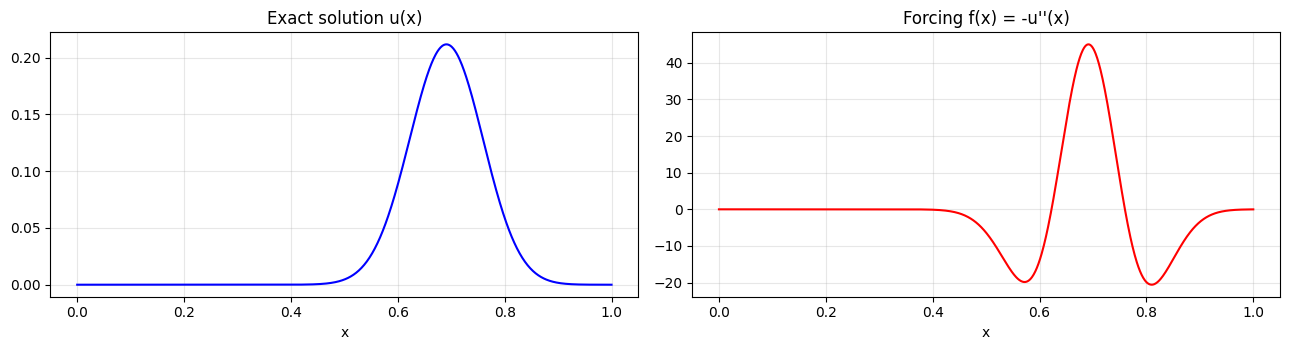

In [38]:
x_sym = sp.symbols('x')
u_sym = x_sym * (1 - x_sym) * sp.exp(-100 * (x_sym - sp.Rational(7, 10)) ** 2)
f_sym = -sp.diff(u_sym, x_sym, 2)
u_func = sp.lambdify(x_sym, u_sym, 'numpy')
f_func = sp.lambdify(x_sym, f_sym, 'numpy')

xs = np.linspace(0, 1, 1001)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(xs, u_func(xs), 'b-')
axes[0].set_title('Exact solution u(x)'); axes[0].grid(alpha=0.3); axes[0].set_xlabel('x')
axes[1].plot(xs, f_func(xs), 'r-')
axes[1].set_title("Forcing f(x) = -u''(x)"); axes[1].grid(alpha=0.3); axes[1].set_xlabel('x')
plt.tight_layout()
plt.show()

## Part 3.2 - Galerkin assembly on a hierarchical basis

We build the stiffness matrix $K_{ij} = \int_0^1 \varphi_i'(x)\, \varphi_j'(x)\, dx$
and load $F_i = \int_0^1 \varphi_i(x)\, f(x)\, dx$ by walking the **integration partition**
from Part 2.3. On each red tile, every active basis function whose support overlaps
contributes - this is the "$B_s \cup B_a$" loop from the thesis.

Quadrature: 4-point Gauss-Legendre per tile (exact for polynomials up to degree 7).

Uniform level-5: 30 DOFs, L^2 error = 6.7480e-05


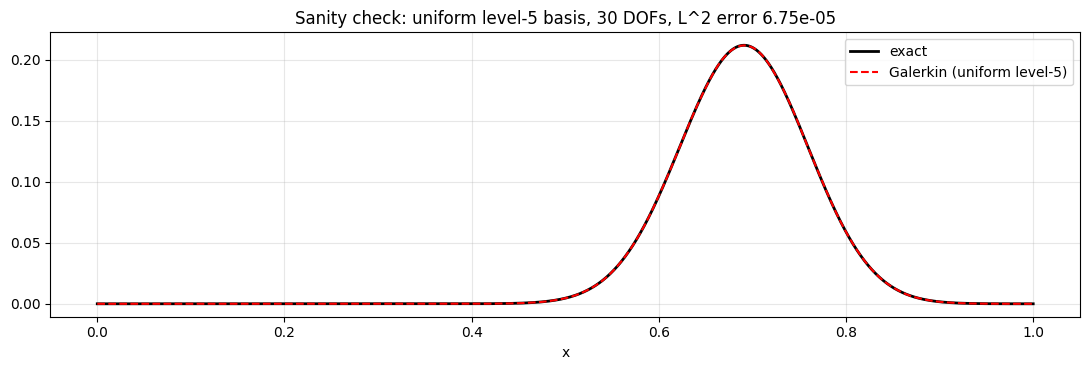

In [39]:
GAUSS_PTS_4 = np.array([-0.8611363115940526, -0.3399810435848563,
                        0.3399810435848563, 0.8611363115940526])
GAUSS_WTS_4 = np.array([0.34785484513745385, 0.6521451548625462,
                        0.6521451548625462, 0.34785484513745385])
GAUSS_PTS_8 = np.array([-0.9602898564975363, -0.7966664774136267, -0.5255324099163290,
                        -0.1834346424956498, 0.1834346424956498, 0.5255324099163290,
                        0.7966664774136267, 0.9602898564975363])
GAUSS_WTS_8 = np.array([0.1012285362903763, 0.2223810344533745, 0.3137066458778873,
                        0.3626837833783620, 0.3626837833783620, 0.3137066458778873,
                        0.2223810344533745, 0.1012285362903763])


def gauss_quad(a, b, order=4):
    pts = GAUSS_PTS_4 if order == 4 else GAUSS_PTS_8
    wts = GAUSS_WTS_4 if order == 4 else GAUSS_WTS_8
    half = 0.5 * (b - a); mid = 0.5 * (a + b)
    return mid + half * pts, half * wts


def integration_partition(basis):
    """Red tiles in 1D dyadic. For simplicity we descend to the finest active level
    over the union of supports - correct, slightly wasteful where coarser would suffice."""
    if not basis.coeffs:
        return []
    max_lvl = max(lvl for (lvl, _) in basis.coeffs)
    needed = set()
    for (lvl, idx) in basis.coeffs:
        scale = 2 ** (max_lvl - lvl)
        for k in range(idx * scale, (idx + 3) * scale):
            needed.add(k)
    return [(max_lvl, k) for k in sorted(needed)]


def assemble(basis, f_func, n_quad=4):
    funcs = sorted(basis.coeffs.keys())
    idx_of = {f: i for i, f in enumerate(funcs)}
    n = len(funcs)
    K = np.zeros((n, n))
    F = np.zeros(n)
    for (lvl, k) in integration_partition(basis):
        h = 2.0 ** (-lvl)
        a, c = k * h, (k + 1) * h
        local = []
        for f in funcs:
            fa, fb = support(*f)
            if fa < c and fb > a:
                local.append(f)
        if not local:
            continue
        xs_q, ws = gauss_quad(a, c, order=n_quad)
        vals = np.array([phi(f[0], f[1], xs_q) for f in local])
        ders = np.array([phi_p(f[0], f[1], xs_q) for f in local])
        f_at = f_func(xs_q)
        for li, fi in enumerate(local):
            ii = idx_of[fi]
            for lj, fj in enumerate(local):
                jj = idx_of[fj]
                K[ii, jj] += np.sum(ws * ders[li] * ders[lj])
            F[ii] += np.sum(ws * vals[li] * f_at)
    return K, F, funcs


def solve(basis, f_func, n_quad=4):
    K, F, funcs = assemble(basis, f_func, n_quad=n_quad)
    coeffs = np.linalg.solve(K, F)
    for f, c in zip(funcs, coeffs):
        basis.coeffs[f] = c
    return coeffs, funcs


def l2_error(basis, u_func, n_pts=10001):
    xs = np.linspace(0, 1, n_pts)
    return float(np.sqrt(np.trapezoid((evaluate(basis, xs) - u_func(xs)) ** 2, xs)))


# Sanity check: solve on a uniform level-5 basis
b = HierarchicalBasis()
for i in range(2 ** 5 - 2):
    b.activate(5, i)
solve(b, f_func, n_quad=8)
err = l2_error(b, u_func)
print(f"Uniform level-5: {len(b)} DOFs, L^2 error = {err:.4e}")

xs = np.linspace(0, 1, 2001)
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(xs, u_func(xs), 'k-', linewidth=2, label='exact')
ax.plot(xs, evaluate(b, xs), 'r--', linewidth=1.5, label='Galerkin (uniform level-5)')
ax.set_title(f'Sanity check: uniform level-5 basis, {len(b)} DOFs, L^2 error {err:.2e}')
ax.set_xlabel('x'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 3.3 - The adaptive loop

We use a residual-based error indicator lumped onto basis functions:

$$\eta_\varphi = \int_{\mathrm{supp}(\varphi)} \varphi(x)\, |f(x) + u_h''(x)|\, dx$$

(since the strong residual is $f - (-u_h'') = f + u_h''$). At each iteration:
solve, compute $\eta_\varphi$ for every active function, refine the top fraction.

In [40]:
def evaluate_pp(basis, xs):
    out = np.zeros_like(xs)
    for (lvl, idx), c in basis.coeffs.items():
        out += c * phi_pp(lvl, idx, xs)
    return out


def per_function_indicator(basis, f_func, n_quad=8):
    eta = {}
    tiles = integration_partition(basis)
    for f_key in basis.coeffs:
        total = 0.0
        f_lvl, f_idx = f_key
        f_a, f_b = support(f_lvl, f_idx)
        for (tl, tk) in tiles:
            th = 2.0 ** (-tl)
            t_a, t_b = tk * th, (tk + 1) * th
            a = max(t_a, f_a); c = min(t_b, f_b)
            if a >= c:
                continue
            xs_q, ws = gauss_quad(a, c, order=n_quad)
            phi_vals = phi(f_lvl, f_idx, xs_q)
            uhpp = evaluate_pp(basis, xs_q)
            total += np.sum(ws * phi_vals * np.abs(f_func(xs_q) + uhpp))
        eta[f_key] = total
    return eta


def adaptive_solve(basis, f_func, u_func, n_iters, refine_fraction=0.3, n_quad=8):
    history = []
    snapshots = []  # list of (iter, coeffs_dict_copy)
    for it in range(n_iters):
        solve(basis, f_func, n_quad=n_quad)
        history.append((len(basis), l2_error(basis, u_func)))
        snapshots.append((it, dict(basis.coeffs)))
        if it == n_iters - 1:
            break
        eta = per_function_indicator(basis, f_func, n_quad=n_quad)
        ranked = sorted(eta.items(), key=lambda kv: -kv[1])
        n_refine = max(1, int(refine_fraction * len(ranked)))
        # Refine top n_refine; coefficients flow to children via Refine
        for f, _ in ranked[:n_refine]:
            if f in basis.coeffs:
                basis.refine(*f)
    return history, snapshots


# Run adaptive
basis_adapt = HierarchicalBasis()
for i in range(2 ** 3 - 2):
    basis_adapt.activate(3, i)
hist_adapt, snaps = adaptive_solve(basis_adapt, f_func, u_func,
                                   n_iters=7, refine_fraction=0.35)
print("Adaptive history (DOFs, L^2 error):")
for n, e in hist_adapt:
    print(f"   {n:5d}  {e:.4e}")

Adaptive history (DOFs, L^2 error):
       6  2.1195e-03
      10  1.1988e-03
      15  2.1395e-04
      24  6.7953e-05
      35  1.4511e-05
      49  4.9997e-06
      71  1.6638e-06


### Where did the active functions concentrate?

Plot the active basis at the final iteration, colored by level. Watch the fine functions
crowd near $x = 0.7$.

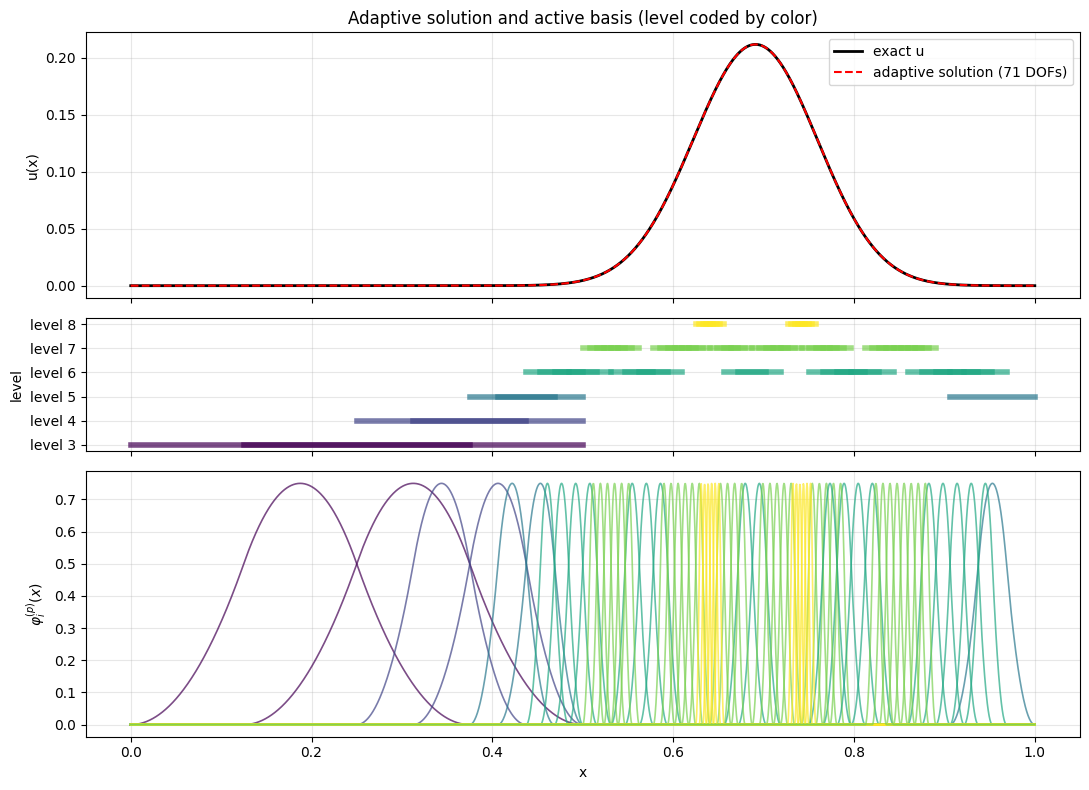

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1, 2]})
xs = np.linspace(0, 1, 2001)
levels_present = sorted({lvl for (lvl, _) in basis_adapt.coeffs})
cmap = plt.cm.viridis
def level_color(lvl):
    return cmap((lvl - levels_present[0]) / max(1, len(levels_present) - 1))

ax = axes[0]
ax.plot(xs, u_func(xs), 'k-', linewidth=2, label='exact u')
ax.plot(xs, evaluate(basis_adapt, xs), 'r--', linewidth=1.5,
        label=f'adaptive solution ({len(basis_adapt)} DOFs)')
ax.set_ylabel('u(x)'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title(f'Adaptive solution and active basis (level coded by color)')

ax = axes[1]
for f_key in basis_adapt.coeffs:
    lvl, idx = f_key
    a, b = support(lvl, idx)
    ax.plot([a, b], [lvl, lvl], '-', color=level_color(lvl), linewidth=4, alpha=0.7)
ax.set_yticks(levels_present)
ax.set_yticklabels([f'level {l}' for l in levels_present])
ax.set_ylabel('level'); ax.grid(alpha=0.3)

ax = axes[2]
for f_key in basis_adapt.coeffs:
    lvl, idx = f_key
    ax.plot(xs, phi(lvl, idx, xs), '-', color=level_color(lvl), linewidth=1.2, alpha=0.7)
ax.set_ylabel(r'$\varphi_i^{(p)}(x)$'); ax.set_xlabel('x'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 3.4 - The money plot: adaptive vs. uniform

Run uniform refinement at levels $p = 3, 4, 5, 6, 7$ and compare $L^2$ error vs. DOFs.
Adaptive should give the same accuracy with a fraction of the DOFs - the ratio is the
whole point of doing adaptivity in the first place.

In [ ]:
hist_uniform = []
for level in [3, 4, 5, 6, 7]:
    b = HierarchicalBasis()
    for i in range(2 ** level - 2):
        b.activate(level, i)
    solve(b, f_func, n_quad=8)
    hist_uniform.append((len(b), l2_error(b, u_func)))
print("\nUniform history (DOFs, L^2 error):")
for n, e in hist_uniform:
    print(f"   {n:5d}  {e:.4e}")

fig, ax = plt.subplots(figsize=(8, 6))
u_dofs, u_errs = zip(*hist_uniform)
a_dofs, a_errs = zip(*hist_adapt)
ax.loglog(u_dofs, u_errs, 'o-', label='Uniform refinement', markersize=8)
ax.loglog(a_dofs, a_errs, 's-', label='Adaptive (basis refinement)', markersize=8, color='C3')
ax.set_xlabel('DOFs (active functions)'); ax.set_ylabel(r'$\|u - u_h\|_{L^2}$')
ax.set_title('Adaptive basis refinement vs. uniform refinement')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

### Where the savings come from

At any fixed error tolerance, draw a horizontal line and read off DOFs on each curve.
Adaptive's slope is steeper because it places fine basis functions only where the
residual is large; uniform pays the same price across the whole domain.

---

## Recap

- We never split a mesh element. Refinement was always **add a finer basis function and
  redistribute coefficients per the refinement relation**.
- The data structures (`coeffs`, `active_elements`, `Bs`, `Ba`) and the operations
  (`Activate`, `Deactivate`, `Refine`) are basis-agnostic. The only basis-specific
  knobs were the support sizes (3 elements for quadratic B-splines) and the refinement
  coefficients (1/4, 3/4, 3/4, 1/4). Swap those out and the same scaffolding handles
  linear hats, Loop subdivision, Catmull-Clark, etc.
- The $L^2$-error vs. DOFs plot makes the adaptive payoff concrete; the colored active
  basis plot makes its *shape* concrete.

**What we skipped (and where the thesis says it matters):**

- **Kraft's construction** for linear independence. Substitution refinement can yield
  a linearly dependent active set - safe for explicit dynamics, fatal for the implicit
  solves needed by stiffness-matrix Poisson. Our patterns happen not to trigger it; the
  thesis ($\S 2.4.2$) gives the fix.
- **Higher dimensions.** The whole *point* of the thesis is that 2D triangles, 3D tets,
  trilinear hexes, and Loop subdivision use the same algorithms - swap the refinement
  coefficients, swap the natural support sets, and `Activate`/`Deactivate` run unchanged.
- **Detail refinement** (the wavelet $V \oplus D$ view). Same mathematical content,
  different mental model - useful when orthogonality matters.

print("\nDone.")